# Japan — Single-Year Piotroski F-Score Walkthrough (2023)

**Pipeline demo:** universe → high-B/M subset → 9-signal F-Score → fixed-basket
selection → equal-weight vs GMV (RMT-cleaned) → metrics vs Monte-Carlo random.

> ⚠️ **Data status:** this notebook currently runs on *clearly-labeled synthetic
> demo data* so the whole pipeline is executable before real adapters land.
> Japan adapters: J-Quants or Refinitiv export (TBD). Swap `make_demo_market` for `load_fundamentals`/`load_prices`
> in `src/fscore/data/loaders.py` — nothing downstream changes.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from fscore.data import make_demo_market, apply_reporting_lag, high_bm_subset
from fscore.signal import piotroski_signals
from fscore.selection import fscore_basket, random_baskets, BASKET_SIZE
from fscore.construction import clean_rmt, equal_weight, gmv_weights
from fscore.evaluation import portfolio_returns, metrics, vs_random

MARKET, YEAR, SEED = "Japan", 2023, 23
fundamentals, prices = make_demo_market(n_stocks=100, year=YEAR, seed=SEED, prefix="JP")
fundamentals = apply_reporting_lag(fundamentals, lag_months=5)
print(f"{MARKET}: {fundamentals.ticker.nunique()} names, fiscal years "
      f"{sorted(fundamentals.fiscal_year.unique())}")

Japan: 100 names, fiscal years [np.int64(2022), np.int64(2023)]


## 1 · Cornerstone: restrict to the high-B/M (value) universe

In [2]:
latest = fundamentals[fundamentals.fiscal_year == YEAR]
value_universe = high_bm_subset(latest, quantile=0.5)   # demo: top half by B/M
print(f"value universe: {len(value_universe)} of {len(latest)} names")

value universe: 50 of 100 names


## 2 · Nine signals, composite F-Score, and its distribution

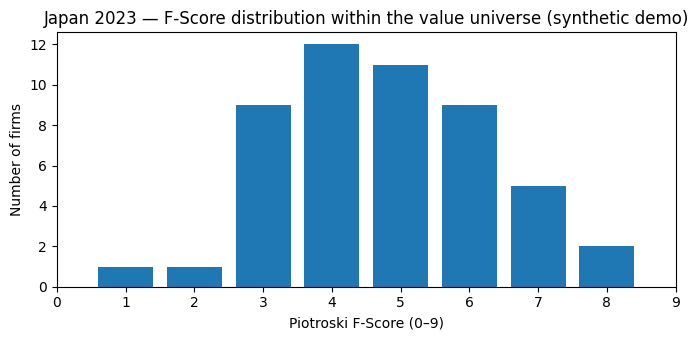

count    50.000000
mean      4.760000
std       1.546028
min       1.000000
25%       4.000000
50%       5.000000
75%       6.000000
max       8.000000
Name: fscore, dtype: float64

In [3]:
scored = piotroski_signals(fundamentals, year=YEAR)
scored = scored[scored.ticker.isin(value_universe.ticker)]
scored = scored.merge(value_universe[["ticker", "bm", "market_cap"]], on="ticker")

fig, ax = plt.subplots(figsize=(7, 3.5))
counts = scored["fscore"].value_counts().sort_index()
ax.bar(counts.index, counts.values)
ax.set_xlabel("Piotroski F-Score (0–9)"); ax.set_ylabel("Number of firms")
ax.set_title(f"{MARKET} {YEAR} — F-Score distribution within the value universe (synthetic demo)")
ax.set_xticks(range(10))
plt.tight_layout(); plt.show()
scored["fscore"].describe()

## 3 · Selection: F-Score top-k basket (fixed size)

In [4]:
k = min(BASKET_SIZE, len(scored) // 2)
basket = fscore_basket(scored, k=k)
print(f"basket size = {k}")
scored[scored.ticker.isin(basket)][["ticker", "fscore", "bm"]].head(10)

basket size = 25


,ticker,fscore,bm
0,JP001,5,0.743983
3,JP007,5,0.999970
4,JP008,7,0.726054
6,JP011,7,0.817911
8,JP015,6,1.535682
9,JP018,5,0.903637
13,JP028,6,0.841251
18,JP037,5,1.026487
19,JP038,5,1.615321
21,JP043,6,1.433859


## 4 · Construction: equal weight vs GMV on RMT-cleaned covariance

In [5]:
hold_start, hold_end = f"{YEAR+1}-04-01", f"{YEAR+1}-12-31"   # post reporting lag
est_px = (prices[prices.ticker.isin(basket)]
          .pivot(index="date", columns="ticker", values="adj_close")
          .loc[:hold_start])
est_rets = est_px.pct_change().dropna()

cov_clean = clean_rmt(est_rets, detone=True)
w_ew  = equal_weight(basket)
w_gmv = gmv_weights(cov_clean, list(est_rets.columns))
print("GMV weight range:", round(w_gmv.min(), 4), "→", round(w_gmv.max(), 4))

GMV weight range: 0.0251 → 0.0504


## 5 · Backtest the holding period, vs the Monte-Carlo random control

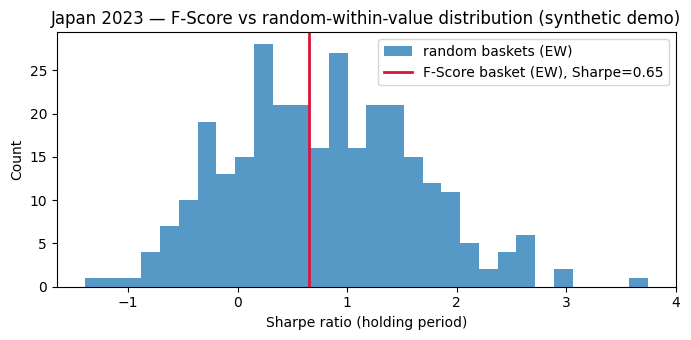

EW metrics: {'cum_return': 0.031, 'ann_return': 0.04, 'ann_vol': 0.062, 'sharpe': 0.65, 'max_drawdown': -0.027}
vs random: {'percentile': 0.467, 'p_value': 0.533, 'n_draws': 300, 'random_mean': 0.775, 'random_std': 0.85}
NOTE: synthetic data ⇒ no signal expected; percentile ≈ uniform. This validates the *pipeline*, not the strategy.


In [6]:
r_ew = portfolio_returns(prices, w_ew, hold_start, hold_end)
m_ew = metrics(r_ew)

rand = random_baskets(list(scored.ticker), k=k, n_draws=300, seed=SEED)
rand_sharpes = [metrics(portfolio_returns(prices, equal_weight(b), hold_start, hold_end)).get("sharpe", np.nan)
                for b in rand]
placement = vs_random(m_ew["sharpe"], rand_sharpes)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist([s for s in rand_sharpes if not np.isnan(s)], bins=30, alpha=0.75, label="random baskets (EW)")
ax.axvline(m_ew["sharpe"], color="crimson", lw=2, label=f"F-Score basket (EW), Sharpe={m_ew['sharpe']:.2f}")
ax.set_xlabel("Sharpe ratio (holding period)"); ax.set_ylabel("Count")
ax.set_title(f"{MARKET} {YEAR} — F-Score vs random-within-value distribution (synthetic demo)")
ax.legend(); plt.tight_layout(); plt.show()

print("EW metrics:", {k_: round(v, 3) for k_, v in m_ew.items()})
print("vs random:", {k_: round(v, 3) for k_, v in placement.items()})
print("NOTE: synthetic data ⇒ no signal expected; percentile ≈ uniform. "
      "This validates the *pipeline*, not the strategy.")

## Next steps (real data)
1. Wire the market's fundamentals/prices adapters in `src/fscore/data/loaders.py`.
2. Confirm delisted coverage + true report dates (gating checks).
3. Extend to annual rebalancing across the full window and add GMV / sector-GMV legs.